In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
from tqdm import tqdm
import os
import time
from datetime import datetime

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data_dic = {
    "CVC_ClinicDB" : 0, # Colonoscopy   - 612 img / 612 mask
    "Darwin": 1,        # X-ray         - 6106 img / 6106 mask
    "DRIVE": 2,         # Fundus        - 40 img / 40 mask
    "DSB_2018": 3,      # Microscopy    - 670 img / 670 mask
    "ISIC_2018": 4,     # Dermoscopy    - 3694 img / 3694 mask
    "Montgomery": 1,    # X-ray         - 138 img / 138 mask
    "PCXA": 1,          # X-ray         - 55 img / 55 mask
    "Shenzhen" : 1,     # X-ray         - 566 img / 566 mask
    "UDIAT" : 5         # Ultrasound    - 163 img / 163 mask
}

idx_name = {
    0: "Colonoscopy",
    1: "X-ray",
    2: "Fundus",
    3: "Microscopy",
    4: "Dermoscopy",
    5: "Ultrasound"
}

In [62]:
datafolder = "../SAM_h_features/image_feature"
files_b = os.listdir(datafolder)
labels_b = []
for f in files_b:
    labels_b.append(data_dic[f.split("_set_file_")[0]])

In [63]:
selected_files_b = []
selected_labels = []
counter = {}

for idx in range(len(files_b)):
    current_idx = labels_b[idx]
    num = counter.get(current_idx, 0)
    if num > 200:
        pass
    else:
        selected_files_b.append(files_b[idx])
        selected_labels.append(labels_b[idx])
        counter[current_idx] = counter.get(current_idx, 0) + 1
    

In [64]:
len(selected_files_b)

1007

In [65]:
labels_name = [idx_name[x] for x in selected_labels]

In [66]:
stacked = []
for i in range(len(selected_files_b)):
    temp = np.array(torch.load(os.path.join(datafolder, selected_files_b[i]))).flatten()
    stacked.append(temp)

In [67]:
stacked_b = np.stack(stacked)

In [68]:
stacked_b.shape

(1007, 1048576)

In [69]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.datasets import make_classification, load_digits
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [70]:
# 设置样式
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = [12, 5]


In [71]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import pandas as pd
import seaborn as sns

# 设置中文字体（如果需要）
# plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
# plt.rcParams['axes.unicode_minus'] = False

# 生成示例数据
np.random.seed(42)

# 特征数据
X = stacked_b
text_labels = labels_name

# 应用t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X)


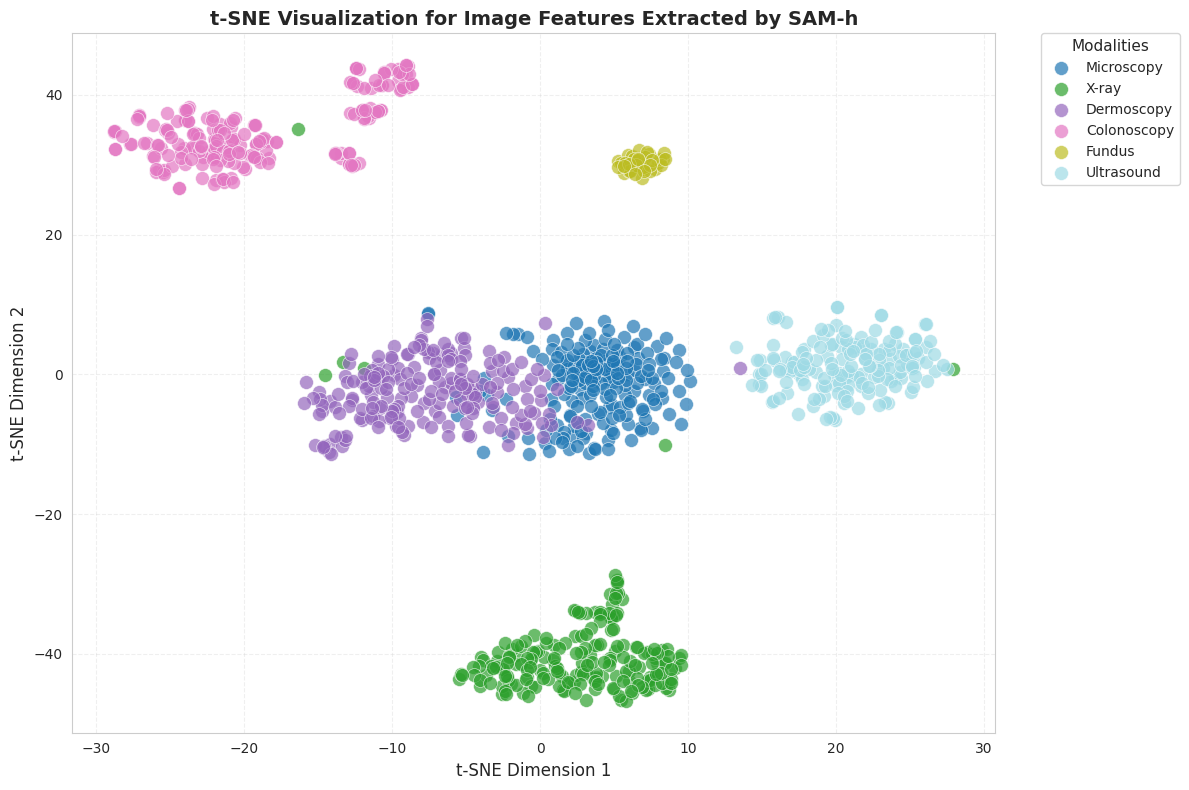

In [72]:
# 创建图形
plt.figure(figsize=(12, 8))

# 获取唯一的文本标签
unique_labels = list(set(text_labels))
n_unique = len(unique_labels)

# 为每个唯一标签创建颜色映射
colors = plt.cm.tab20(np.linspace(0, 1, n_unique))
label_to_color = {label: colors[i] for i, label in enumerate(unique_labels)}

# 绘制散点图
for label in unique_labels:
    # 找到该标签对应的数据点索引
    indices = [i for i, l in enumerate(text_labels) if l == label]
    
    if indices:  # 确保有数据点
        plt.scatter(X_tsne[indices, 0], X_tsne[indices, 1],
                   c=[label_to_color[label]], label=label,
                   alpha=0.7, s=100, edgecolors='white', linewidth=0.5)

plt.xlabel('t-SNE Dimension 1', fontsize=12)
plt.ylabel('t-SNE Dimension 2', fontsize=12)
plt.title('t-SNE Visualization for Image Features Extracted by SAM-h', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, linestyle='--')

# 添加图例
plt.legend(title='Modalities', bbox_to_anchor=(1.05, 1), loc='upper left', 
           borderaxespad=0., fontsize=10, title_fontsize=11)

plt.tight_layout()
plt.show()